In [1]:
import os
from pathlib import Path

project_root = "somedir/freqtrade"
i=0
try:
    os.chdirdir(project_root)
    assert Path('docker-compose.yml').is_file()
except:
    while i<4 and (not Path('docker-compose.yml').is_file()):
        os.chdir(Path(Path.cwd(), '../'))
        i+=1
    project_root = Path.cwd()
print(Path.cwd())

/root/defi


In [2]:
from freqtrade.configuration import Configuration

url = "user_data/cluster_strategy_v4_config.json"
config = Configuration.from_files([url])
config["strategy"] = "ClusterStrategyV4"
data_location = config["datadir"]
pair = 'WIF/USDT:USDT'

In [ ]:
!freqtrade download-data -c $url --pairs $pair -t 1m 3m

In [5]:
from freqtrade.data.history import load_pair_history
from freqtrade.enums import CandleType

dataframe_1m = load_pair_history(
    datadir=data_location,
    timeframe='1m',
    pair=pair,
    data_format = "feather",
    candle_type=CandleType.FUTURES,
)

In [61]:
dataframe_3m = load_pair_history(
    datadir=data_location,
    timeframe='3m',
    pair=pair,
    data_format = "feather",
    candle_type=CandleType.FUTURES,
)

In [1]:
import numpy as np

In [2]:
from freqtrade.strategy import stoploss_from_absolute

In [186]:
risk, current_rate = 0.005, 0.412
open_rate = 0.41
stop, reward = open_rate * (1 - risk), open_rate * (1 + 2 * risk)

In [228]:
borders = np.arange(0,1,0.1)
borders = np.sort(np.append(borders, (stop, open_rate, reward)))
border = borders[(borders < current_rate) & (borders >= stop)][-2]
stop = border if border > stop else stop
current_rate += 0.01
print(stop)
stoploss_from_absolute(stop, current_rate, False, 1)

0.5


0.0

In [370]:
risk, current_rate = 0.005, 0.409
open_rate = 0.41
stop, reward = open_rate / (1 - risk), open_rate / (1 + 2 * risk)

In [418]:
borders = np.arange(0,1,0.1)
borders = np.flip(np.sort(np.append(borders, (stop, open_rate, reward))))
border = borders[(borders > current_rate) & (borders <= stop)][-2]
stop = border if border < stop else stop
current_rate -= 0.01
print(f"borders: {borders}")
print(f"border: {border}")
print(f"stop: {stop}")
print(f"current_rate: {current_rate}")
stoploss_from_absolute(stop, current_rate, True, 1)

borders: [0.9        0.8        0.7        0.6        0.5        0.41
 0.40594059 0.4        0.3        0.2        0.1        0.1
 0.        ]
border: 0.1
stop: 0.1
current_rate: -0.06100000000000026


0.0

In [1]:
import numpy as np

In [2]:
borders = np.arange(0,10,1)
borders

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [77]:
from freqtrade_client import FtRestClient
import pandas as pd
from datetime import date, timedelta

In [2]:
server_url = 'http://127.0.0.1:8080'
username = ''
password = "a88923695f80935a17b99e51df8275bc3440b92defa52106c0cea26ca1bf1ce1"
client = FtRestClient(server_url, username, password)

In [83]:
starting_balance = client.daily(1).get('data')[0].get('starting_balance')
dataframe = pd.DataFrame(client.trades().get('trades'))
dataframe['rel_stake'] = dataframe['stake_amount'] / starting_balance
dataframe['rel_profit'] = dataframe['close_profit_pct'] * dataframe['rel_stake']
rel_profit = dataframe[
    (dataframe.close_date > (date.today() - timedelta(days=1)).strftime('%Y-%m-%d')) &
    (dataframe.close_profit_pct > 0)
].rel_profit.sum()
rel_profit

8.591147258713216

In [6]:
stoploss = -0.02
max_stake = 300
min_stake = 5
risk = 0.3
max(min(max_stake * abs(stoploss) / risk, max_stake), min_stake)

20.0

In [27]:
import pandas as pd
from scipy.signal import argrelextrema
import numpy as np
import math

In [89]:
dataframe = pd.read_csv("out.csv")
# dataframe = dataframe[['date','open','high','low','close','volume']]
dataframe['date'] = pd.to_datetime(dataframe['date'])
# dataframe[['date','&s-up_or_down']].tail()

In [90]:
dataframe.columns[dataframe.columns.str.startswith('%')]

Index(['%%-day_of_week_cos', '%%-hour_of_day_cos', '%%-day_of_week_sin',
       '%%-hour_of_day_sin'],
      dtype='object')

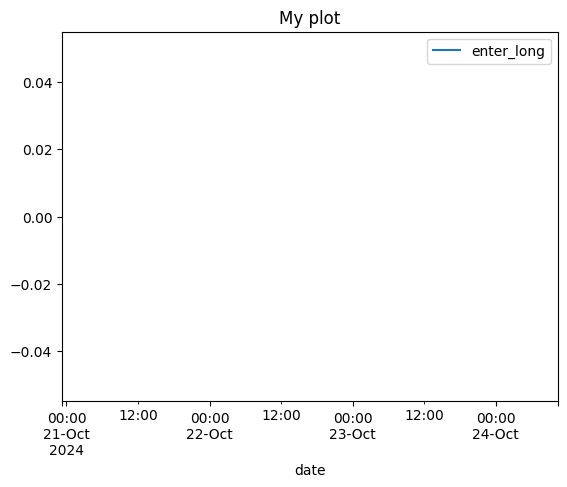

In [91]:
plot = dataframe.plot(kind='line', x='date', y='enter_long', title="My plot")

In [1]:
import datetime

In [19]:
before = datetime.datetime.now()

In [25]:
(datetime.datetime.now() - before).days

0